# RPG Cold-Start Analysis

This notebook loads cold-start result sessions from both the shared group artifacts tree and the repo-local home artifacts tree, then builds reporting tables and plots for the latest available run of each dataset and config track.

Expected layouts:

```text
<artifact-root>/rpg/cold_start/<track>/<dataset>/<session>/tables/cold_start_summary.json
<artifact-root>/rpg/cold_start/<session>/tables/cold_start_summary.json
```

The second form is the older single-session layout and is labeled `legacy` in the tables below.


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

ROOT = Path.cwd().resolve()
while ROOT.name != "RPG":
    ROOT = ROOT.parent

HOME_ARTIFACT_ROOT = ROOT / "artifacts" / "rpg" / "cold_start"
GROUP_ARTIFACT_ROOT = Path("/projects/prjs2120/groups/group_16/artifacts/rpg/cold_start")
ARTIFACT_ROOTS = []
for candidate in (GROUP_ARTIFACT_ROOT, HOME_ARTIFACT_ROOT):
    if candidate not in ARTIFACT_ROOTS:
        ARTIFACT_ROOTS.append(candidate)

METRIC_ORDER = ["recall@5", "ndcg@5", "recall@10", "ndcg@10"]
PRIMARY_METRIC = "ndcg@10"
TRACK_LABELS = {
    "released_readme": "released README",
    "paper_appendix": "paper appendix",
    "legacy": "legacy",
}
DATASET_LABELS = {
    "Sports_and_Outdoors": "Sports",
    "sports_and_outdoors": "Sports",
    "Beauty": "Beauty",
    "beauty": "Beauty",
    "Toys_and_Games": "Toys",
    "toys_and_games": "Toys",
    "CDs_and_Vinyl": "CDs",
    "cds_and_vinyl": "CDs",
}
DATASET_ORDER = ["Sports", "Beauty", "Toys", "CDs"]
TRACK_ORDER = ["released README", "paper appendix", "legacy"]


In [2]:
def _dataset_label(raw_value: str | None) -> str:
    if raw_value is None:
        return "Unknown"
    return DATASET_LABELS.get(raw_value, raw_value)


def _track_label(raw_value: str) -> str:
    return TRACK_LABELS.get(raw_value, raw_value)


def _run_sort_key(row: pd.Series) -> tuple[int, int, str, str]:
    dataset_rank = DATASET_ORDER.index(row["dataset"]) if row["dataset"] in DATASET_ORDER else len(DATASET_ORDER)
    track_rank = TRACK_ORDER.index(row["track_label"]) if row["track_label"] in TRACK_ORDER else len(TRACK_ORDER)
    return dataset_rank, track_rank, row["track"], row["session"]


def _parse_summary(summary_path: Path, artifact_root: Path) -> tuple[dict, list[dict]]:
    payload = json.loads(summary_path.read_text())
    session_root = summary_path.parents[1]
    relative_parts = summary_path.relative_to(artifact_root).parts

    if len(relative_parts) >= 5 and relative_parts[-2] == "tables":
        track = relative_parts[0]
        dataset_slug = relative_parts[1]
        session = relative_parts[2]
    else:
        track = "legacy"
        dataset_slug = payload.get("category") or payload.get("dataset") or "unknown"
        session = session_root.name

    overall_results = payload.get("overall_results", {})
    group_rows = payload.get("group_rows", [])
    checkpoint_path = payload.get("checkpoint_path")
    row = {
        "artifact_root": str(artifact_root),
        "summary_path": str(summary_path),
        "session_root": str(session_root),
        "session": session,
        "track": track,
        "track_label": _track_label(track),
        "dataset_slug": dataset_slug,
        "dataset": _dataset_label(payload.get("category") or dataset_slug),
        "category": payload.get("category"),
        "bucket_spec": payload.get("bucket_spec"),
        "checkpoint_path": checkpoint_path,
        "checkpoint_name": None if checkpoint_path is None else Path(checkpoint_path).name,
        "plot_metric": payload.get("plot_metric"),
    }
    for metric_name in METRIC_ORDER:
        row[metric_name] = overall_results.get(metric_name)
    row["n_buckets"] = len(group_rows)

    bucket_rows = []
    for bucket in group_rows:
        bucket_row = {
            "artifact_root": str(artifact_root),
            "summary_path": str(summary_path),
            "session_root": str(session_root),
            "session": session,
            "track": track,
            "track_label": _track_label(track),
            "dataset_slug": dataset_slug,
            "dataset": _dataset_label(payload.get("category") or dataset_slug),
            "bucket_label": bucket.get("bucket_label"),
            "bucket_range": bucket.get("bucket_range"),
            "bucket_min_count": bucket.get("bucket_min_count"),
            "bucket_max_count": bucket.get("bucket_max_count"),
            "n_examples": bucket.get("n_examples", 0),
        }
        for metric_name in METRIC_ORDER + ["n_visited_items"]:
            bucket_row[metric_name] = bucket.get(metric_name)
        bucket_rows.append(bucket_row)
    return row, bucket_rows


run_rows = []
bucket_rows = []
for artifact_root in ARTIFACT_ROOTS:
    if not artifact_root.exists():
        continue
    for summary_path in sorted(artifact_root.rglob("cold_start_summary.json")):
        parsed_run, parsed_buckets = _parse_summary(summary_path, artifact_root)
        run_rows.append(parsed_run)
        bucket_rows.extend(parsed_buckets)

all_runs = pd.DataFrame(run_rows)
all_buckets = pd.DataFrame(bucket_rows)

if all_runs.empty:
    joined_roots = "\n".join(str(path) for path in ARTIFACT_ROOTS)
    print(f"No cold_start_summary.json files found under:\n{joined_roots}")
    latest_runs = pd.DataFrame()
    latest_buckets = pd.DataFrame()
else:
    latest_runs = (
        all_runs.sort_values(["dataset", "track", "session"])
        .groupby(["dataset", "track"], as_index=False)
        .tail(1)
        .reset_index(drop=True)
    )
    latest_keys = latest_runs[["dataset", "track", "session"]]
    latest_buckets = all_buckets.merge(latest_keys, on=["dataset", "track", "session"], how="inner")

    latest_runs = latest_runs.sort_values(
        by=["dataset", "track_label", "session"],
        key=lambda col: col,
    ).reset_index(drop=True)
    latest_buckets = latest_buckets.sort_values(
        ["dataset", "track_label", "bucket_min_count"],
    ).reset_index(drop=True)

print(f"Discovered {len(all_runs)} cold-start runs across {sum(path.exists() for path in ARTIFACT_ROOTS)} artifact roots.")


Discovered 5 cold-start runs across 1 artifact roots.


## Table 1: Latest Run Overview

This table keeps one latest session per `(dataset, track)` pair and shows the overall cold-start metrics stored in the summary payload.


In [3]:
if latest_runs.empty:
    print("No cold-start runs available.")
else:
    overview = latest_runs[
        [
            "dataset",
            "track_label",
            "session",
            "bucket_spec",
            "recall@5",
            "ndcg@5",
            "recall@10",
            "ndcg@10",
            "checkpoint_name",
            "artifact_root",
        ]
    ].copy()
    overview = overview.rename(columns={"track_label": "track"})
    overview = overview.sort_values(
        by=["dataset", "track", "session"],
        key=lambda col: col.map({name: idx for idx, name in enumerate(DATASET_ORDER + TRACK_ORDER)}) if col.name in {"dataset", "track"} else col,
    ).reset_index(drop=True)
    display(overview)


,dataset,track,session,bucket_spec,recall@5,ndcg@5,recall@10,ndcg@10,checkpoint_name,artifact_root
0,Sports,released README,20260610T154132050775Z_job23641324,"0-5,6-10,11-15,16-20",0.029721,0.020780,0.044328,0.025482,rpg_repro_sports_and_outdoors-scripts|rpg.py_-...,/gpfs/home6/scur1202/RPG/artifacts/rpg/cold_start
1,Sports,legacy,20260606T195305070147Z_job23540260,"0-5,6-10,11-15,16-20",0.029721,0.020780,0.044328,0.025482,rpg_repro_sports_and_outdoors-scriptsrpg.py_--...,/gpfs/home6/scur1202/RPG/artifacts/rpg/cold_start
2,Beauty,released README,20260610T154350059788Z_job23642074,"0-5,6-10,11-15,16-20",0.054286,0.037750,0.078478,0.045563,rpg_repro_beauty-scripts|rpg.py_--preset_beaut...,/gpfs/home6/scur1202/RPG/artifacts/rpg/cold_start
3,Toys,released README,20260610T154412858215Z_job23642075,"0-5,6-10,11-15,16-20",0.057799,0.039101,0.086184,0.048252,rpg_repro_toys_and_games-scripts|rpg.py_--pres...,/gpfs/home6/scur1202/RPG/artifacts/rpg/cold_start
4,CDs,released README,20260610T154422093427Z_job23642084,"0-5,6-10,11-15,16-20",0.050652,0.034350,0.074105,0.041906,rpg_repro_cds_and_vinyl-scripts|rpg.py_--prese...,/gpfs/home6/scur1202/RPG/artifacts/rpg/cold_start


## Table 2: Bucket-Level Metrics

The first table pivots the primary metric by training-frequency bucket. The second table shows how many test examples fall into each bucket.


In [4]:
if latest_buckets.empty:
    print("No bucket-level rows available.")
else:
    metric_table = latest_buckets.pivot_table(
        index=["dataset", "track_label"],
        columns="bucket_range",
        values=PRIMARY_METRIC,
        aggfunc="first",
    )
    metric_table = metric_table.reset_index().rename(columns={"track_label": "track"})
    metric_table = metric_table.sort_values(
        by=["dataset", "track"],
        key=lambda col: col.map({name: idx for idx, name in enumerate(DATASET_ORDER + TRACK_ORDER)}) if col.name in {"dataset", "track"} else col,
    ).reset_index(drop=True)
    print(f"Primary metric by bucket: {PRIMARY_METRIC}")
    display(metric_table)

    count_table = latest_buckets.pivot_table(
        index=["dataset", "track_label"],
        columns="bucket_range",
        values="n_examples",
        aggfunc="first",
    )
    count_table = count_table.reset_index().rename(columns={"track_label": "track"})
    count_table = count_table.sort_values(
        by=["dataset", "track"],
        key=lambda col: col.map({name: idx for idx, name in enumerate(DATASET_ORDER + TRACK_ORDER)}) if col.name in {"dataset", "track"} else col,
    ).reset_index(drop=True)
    print("Test examples per bucket")
    display(count_table)


Primary metric by bucket: ndcg@10


bucket_range,dataset,track,"[0, 5]","[11, 15]","[16, 20]","[6, 10]"
0,Sports,released README,0.004514,0.017149,0.019908,0.012001
1,Sports,legacy,0.004514,0.017149,0.019908,0.012001
2,Beauty,released README,0.014827,0.040687,0.034003,0.020594
3,Toys,released README,0.025242,0.061039,0.063975,0.037882
4,CDs,released README,0.001351,0.010876,0.016091,0.003736


Test examples per bucket


bucket_range,dataset,track,"[0, 5]","[11, 15]","[16, 20]","[6, 10]"
0,Sports,released README,9962,3794,2585,6816
1,Sports,legacy,9962,3794,2585,6816
2,Beauty,released README,6197,2538,1529,4261
3,Toys,released README,6249,2226,1454,4011
4,CDs,released README,13139,7542,5754,12847


## Plot 1: Primary Metric by Bucket

Each subplot corresponds to one dataset. Bars are grouped by config track.


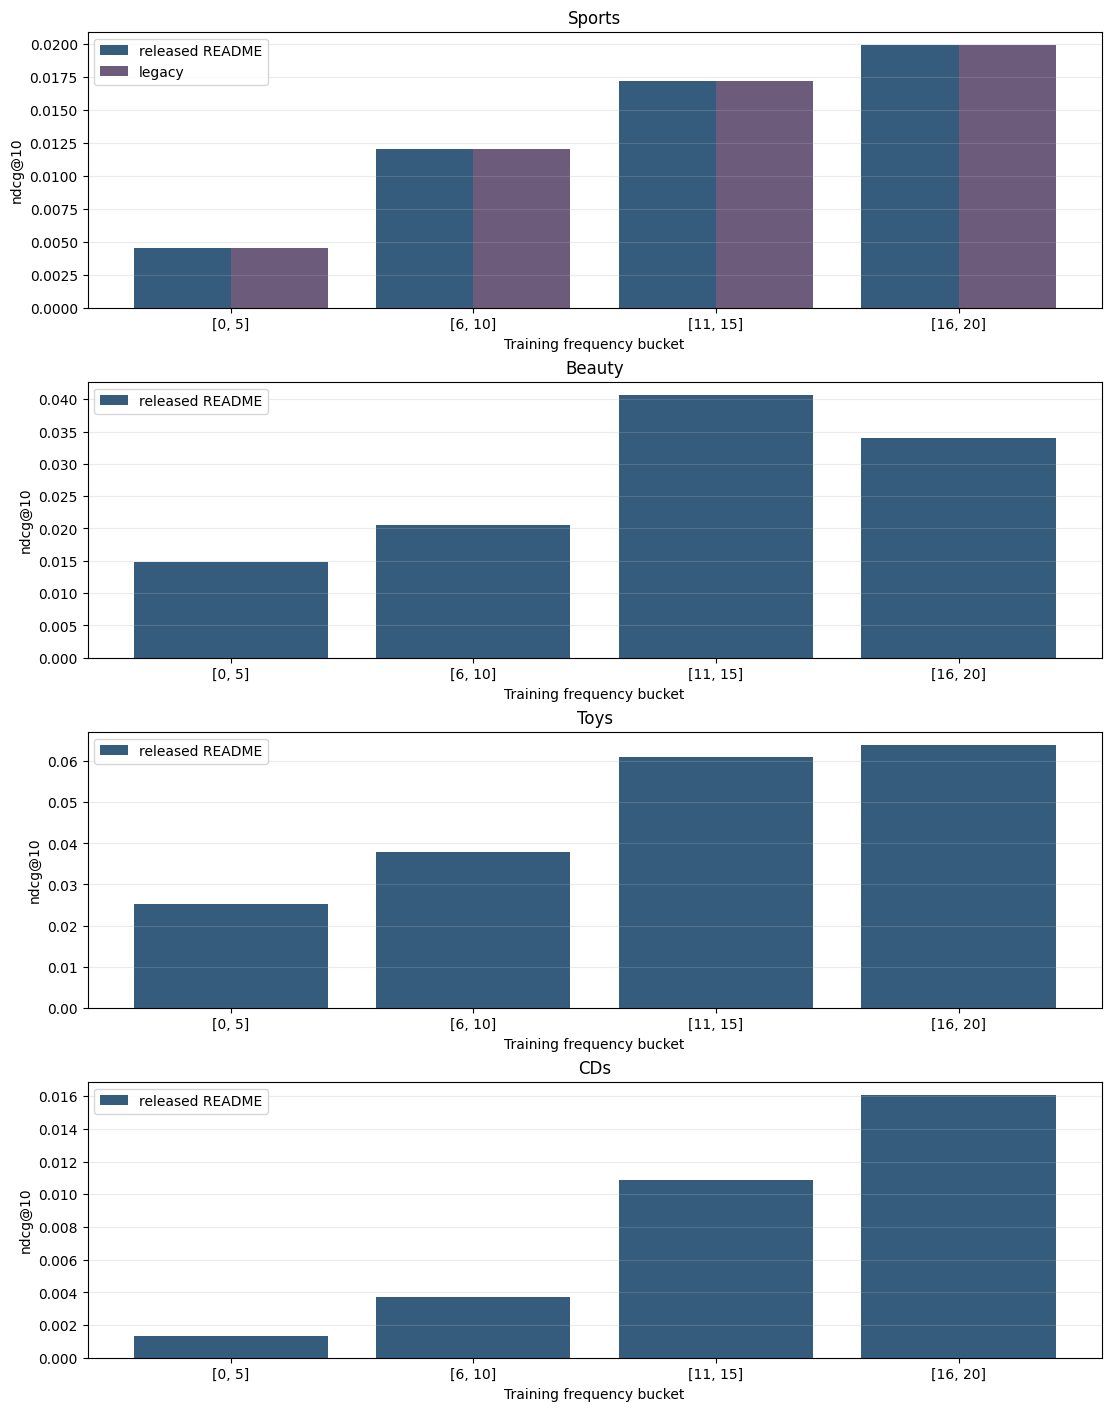

In [5]:
if latest_buckets.empty:
    print("No bucket-level rows available.")
else:
    datasets = [name for name in DATASET_ORDER if name in set(latest_buckets["dataset"])]
    if not datasets:
        datasets = sorted(set(latest_buckets["dataset"]))
    figure, axes = plt.subplots(len(datasets), 1, figsize=(11, 3.5 * len(datasets)), constrained_layout=True)
    if len(datasets) == 1:
        axes = [axes]

    color_map = {
        "released README": "#355C7D",
        "paper appendix": "#C06C84",
        "legacy": "#6C5B7B",
    }

    for axis, dataset in zip(axes, datasets):
        frame = latest_buckets[latest_buckets["dataset"] == dataset].copy()
        buckets = frame.sort_values("bucket_min_count")["bucket_range"].drop_duplicates().tolist()
        tracks = [track for track in TRACK_ORDER if track in set(frame["track_label"])]
        if not tracks:
            tracks = sorted(set(frame["track_label"]))
        x = np.arange(len(buckets), dtype=float)
        width = 0.8 / max(len(tracks), 1)

        for index, track in enumerate(tracks):
            track_frame = frame[frame["track_label"] == track].sort_values("bucket_min_count")
            values = [
                float(track_frame.loc[track_frame["bucket_range"] == bucket, PRIMARY_METRIC].iloc[0])
                if not track_frame.loc[track_frame["bucket_range"] == bucket, PRIMARY_METRIC].empty
                else np.nan
                for bucket in buckets
            ]
            offsets = x - 0.4 + width / 2 + index * width
            axis.bar(offsets, values, width=width, label=track, color=color_map.get(track, None))

        axis.set_title(dataset)
        axis.set_xlabel("Training frequency bucket")
        axis.set_ylabel(PRIMARY_METRIC)
        axis.set_xticks(x)
        axis.set_xticklabels(buckets)
        axis.grid(axis="y", alpha=0.25)
        axis.set_ylim(bottom=0)
        axis.legend(loc="upper left")

    plt.show()


## Plot 2: Test Example Counts by Bucket

This plot helps interpret whether a bucket-level metric is based on a large or small slice of the test set.


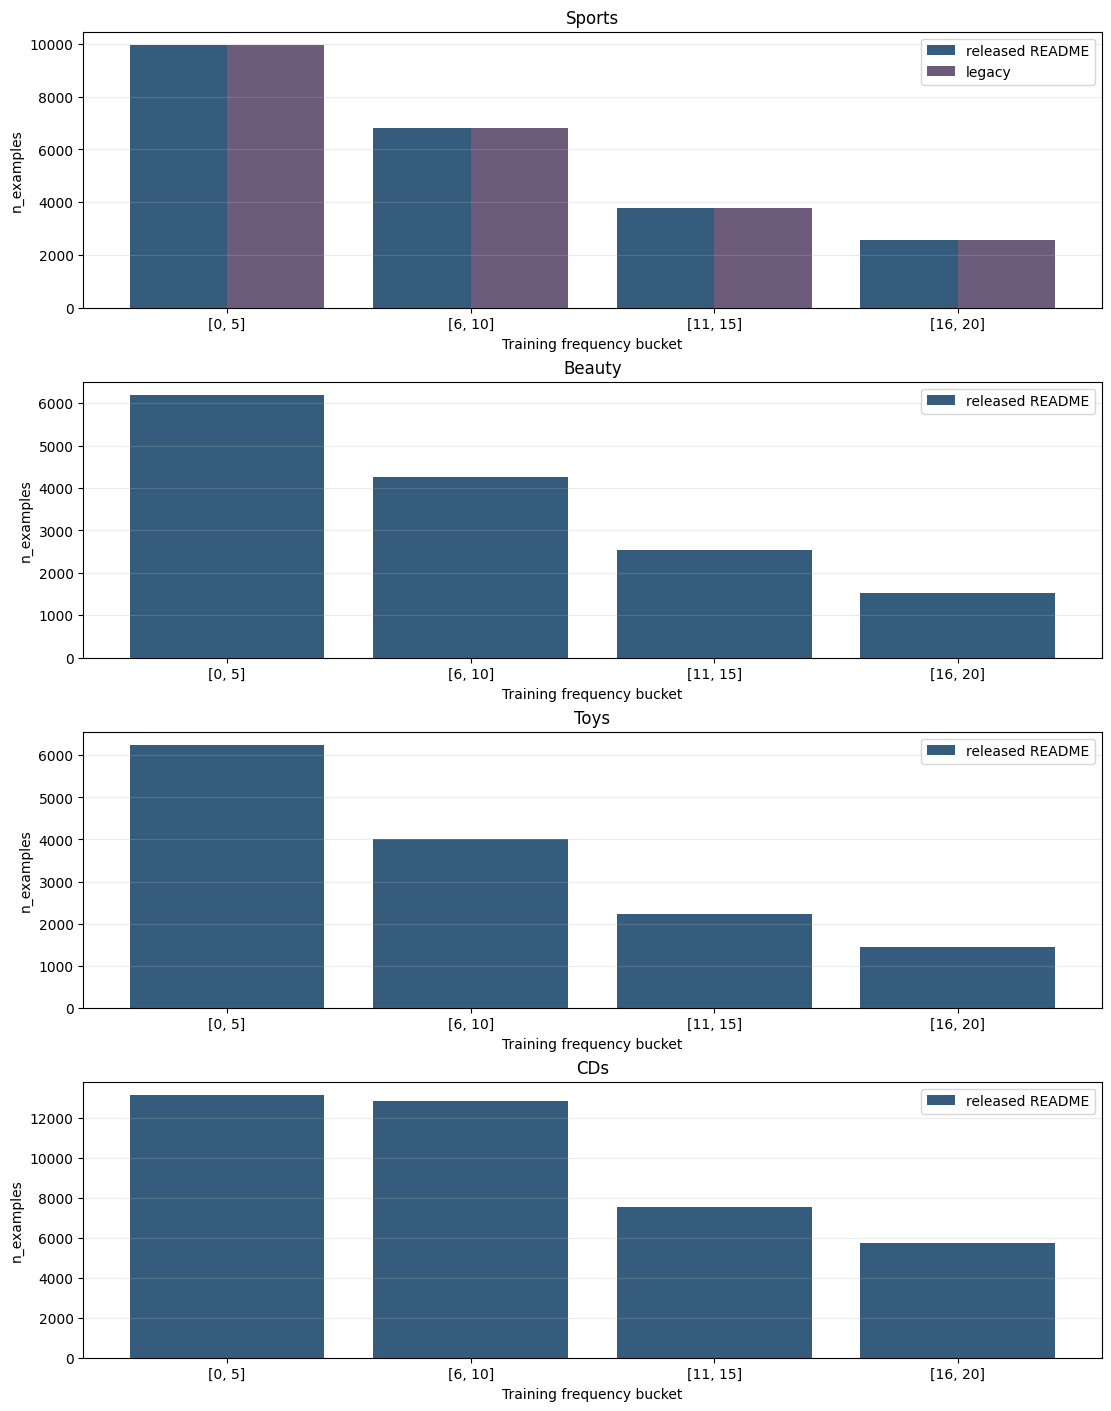

In [6]:
if latest_buckets.empty:
    print("No bucket-level rows available.")
else:
    datasets = [name for name in DATASET_ORDER if name in set(latest_buckets["dataset"])]
    if not datasets:
        datasets = sorted(set(latest_buckets["dataset"]))
    figure, axes = plt.subplots(len(datasets), 1, figsize=(11, 3.5 * len(datasets)), constrained_layout=True)
    if len(datasets) == 1:
        axes = [axes]

    color_map = {
        "released README": "#355C7D",
        "paper appendix": "#C06C84",
        "legacy": "#6C5B7B",
    }

    for axis, dataset in zip(axes, datasets):
        frame = latest_buckets[latest_buckets["dataset"] == dataset].copy()
        buckets = frame.sort_values("bucket_min_count")["bucket_range"].drop_duplicates().tolist()
        tracks = [track for track in TRACK_ORDER if track in set(frame["track_label"])]
        if not tracks:
            tracks = sorted(set(frame["track_label"]))
        x = np.arange(len(buckets), dtype=float)
        width = 0.8 / max(len(tracks), 1)

        for index, track in enumerate(tracks):
            track_frame = frame[frame["track_label"] == track].sort_values("bucket_min_count")
            values = [
                float(track_frame.loc[track_frame["bucket_range"] == bucket, "n_examples"].iloc[0])
                if not track_frame.loc[track_frame["bucket_range"] == bucket, "n_examples"].empty
                else np.nan
                for bucket in buckets
            ]
            offsets = x - 0.4 + width / 2 + index * width
            axis.bar(offsets, values, width=width, label=track, color=color_map.get(track, None))

        axis.set_title(dataset)
        axis.set_xlabel("Training frequency bucket")
        axis.set_ylabel("n_examples")
        axis.set_xticks(x)
        axis.set_xticklabels(buckets)
        axis.grid(axis="y", alpha=0.25)
        axis.legend(loc="upper right")

    plt.show()
